# CIFAR-10 Pre-trained Model Result

This notebook loads a model that has already been fine-tuned on CIFAR-10 and evaluates it on the official CIFAR-10 test set.

There is no training in this notebook. The goal is to show the result from a ready-to-use model.

Model used: [`aaraki/vit-base-patch16-224-in21k-finetuned-cifar10`](https://huggingface.co/aaraki/vit-base-patch16-224-in21k-finetuned-cifar10).

The model card reports **0.9788 accuracy** on its evaluation set. This notebook checks that result directly on the Keras CIFAR-10 test set.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from tensorflow.keras.datasets import cifar10
from transformers import AutoImageProcessor, AutoModelForImageClassification

np.random.seed(42)
torch.manual_seed(42)

(_, _), (X_test, y_test) = cifar10.load_data()
y_test = y_test.flatten()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_test: (10000, 32, 32, 3)
y_test: (10000,)


## Load the Pre-trained CIFAR-10 Model

The first run may download the model from Hugging Face. After that, it will load from the local cache.

In [2]:
checkpoint = 'aaraki/vit-base-patch16-224-in21k-finetuned-cifar10'

processor = AutoImageProcessor.from_pretrained(checkpoint, use_fast=False)
model = AutoModelForImageClassification.from_pretrained(checkpoint)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model.to(device)
model.eval()

model_labels = [model.config.id2label[i] for i in range(10)]

if model_labels != class_names:
    raise ValueError(
        'The downloaded model labels do not match CIFAR-10 labels.\n'
        f'Model labels: {model_labels}\n'
        f'CIFAR-10 labels: {class_names}'
    )

print('Checkpoint:', checkpoint)
print('Device:', device)
print('Labels:', model_labels)

Checkpoint: aaraki/vit-base-patch16-224-in21k-finetuned-cifar10
Device: mps
Labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Evaluate on the Full CIFAR-10 Test Set

This runs inference on all 10,000 official CIFAR-10 test images. It is not training the model.

In [3]:
BATCH_SIZE = 64
NUM_TEST_IMAGES = len(X_test)

pretrained_preds = []
pretrained_confidences = []

start_time = time.time()

for start in range(0, NUM_TEST_IMAGES, BATCH_SIZE):
    end = min(start + BATCH_SIZE, NUM_TEST_IMAGES)

    batch_images = [Image.fromarray(img) for img in X_test[start:end]]
    inputs = processor(images=batch_images, return_tensors='pt')
    inputs = {name: tensor.to(device) for name, tensor in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=1)
        confidences, predictions = probabilities.max(dim=1)

    pretrained_preds.extend(predictions.cpu().numpy())
    pretrained_confidences.extend(confidences.cpu().numpy())

    if end % 2000 == 0 or end == NUM_TEST_IMAGES:
        print(f'Processed {end}/{NUM_TEST_IMAGES} images')

pretrained_preds = np.array(pretrained_preds)
pretrained_confidences = np.array(pretrained_confidences)

correct = int(np.sum(pretrained_preds == y_test[:NUM_TEST_IMAGES]))
accuracy = correct / NUM_TEST_IMAGES
elapsed = time.time() - start_time

print(f'Correct predictions: {correct}/{NUM_TEST_IMAGES}')
print(f'Accuracy: {accuracy:.4f}')
print(f'Elapsed time: {elapsed:.2f} seconds')

Processed 8000/10000 images


Processed 10000/10000 images
Correct predictions: 9788/10000
Accuracy: 0.9788
Elapsed time: 131.15 seconds


## Visualise Some Predictions

The sample is fixed with a random seed so the notebook is reproducible.

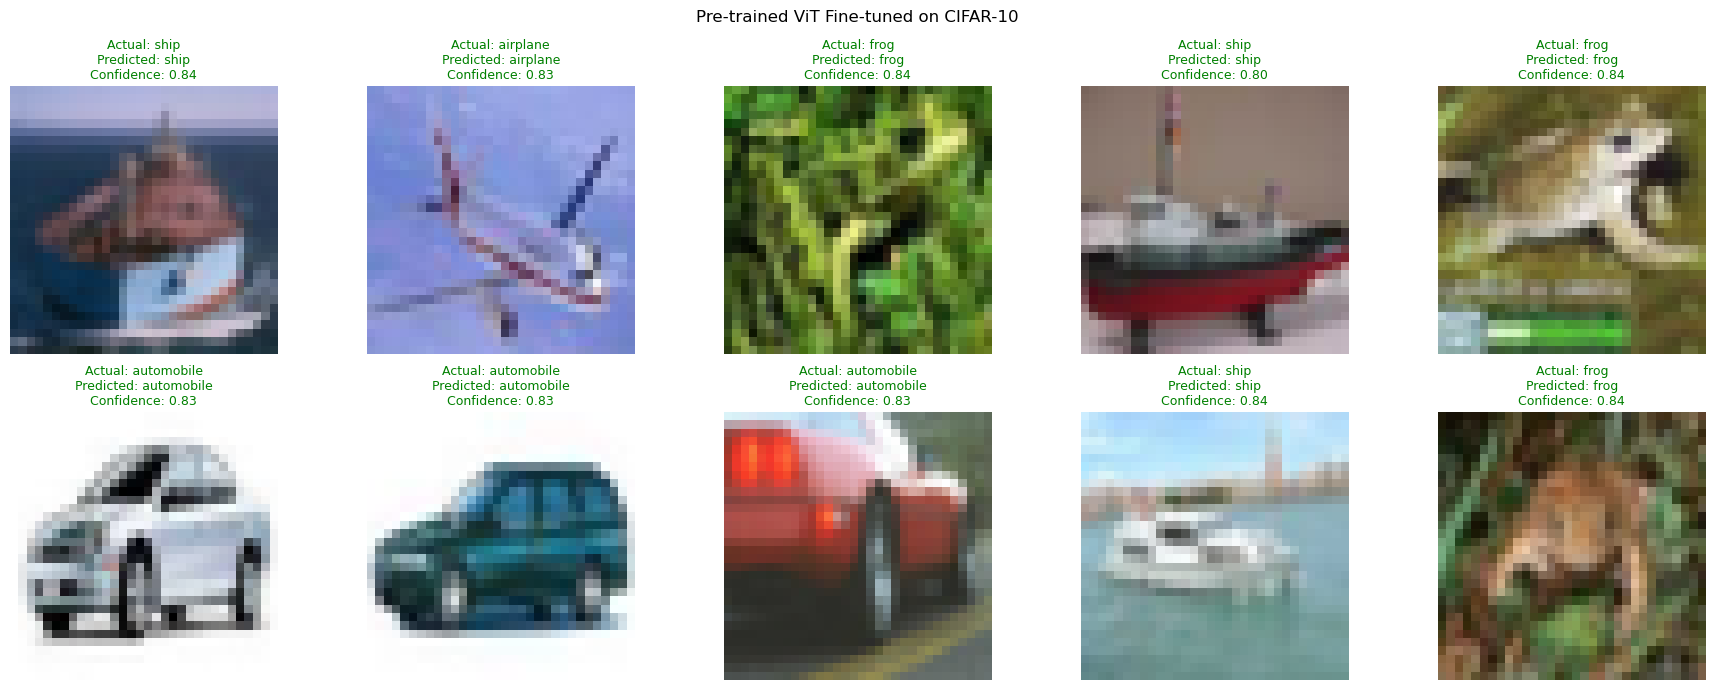

In [4]:
rng = np.random.default_rng(42)
sample_indices = rng.choice(NUM_TEST_IMAGES, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    actual_label = class_names[y_test[idx]]
    predicted_label = class_names[pretrained_preds[idx]]
    confidence = pretrained_confidences[idx]

    title_color = 'green' if actual_label == predicted_label else 'red'

    ax.imshow(X_test[idx])
    ax.set_title(
        f'Actual: {actual_label}\n'
        f'Predicted: {predicted_label}\n'
        f'Confidence: {confidence:.2f}',
        fontsize=9,
        color=title_color
    )
    ax.axis('off')

plt.suptitle('Pre-trained ViT Fine-tuned on CIFAR-10')
plt.tight_layout()
plt.show()